### **Time Series Forecasting: Projected stock price forecast using statistical methods**

In this exercise, I will be studying the ARIMA model and how it conducts time series analysis on a closing stock price. In addition to this, the second part of the notebook includes forecasting using the `Prophet` framework.

ARIMA (Auto-Regressive Integrated Moving Average) is a common forecasting technique used for forecasting a time series. The equation for the model is linear and comprises of three parts:

1. Autoregressive (patterns): relates the current value of the series to its past values using a linear relationship; lags of the stationarized series.
2. Integrated (trends): involves adjusting for trends like seasonal growth; statistical properties like mean and variance remain unchanged over time
3. Moving Average (corrections for surprises): Models the relationship between current value and past forecast errors; lags of the forecast errors.

The ARIMA model is defined as ARIMA(p, d, q), where p, d, q represent the model parameters:
- p: number of autoregressive terms in the model
- d: number of times the raw observations are differenced to make the series stationary
- q: size of the moving average window/number of lagged forecast errors.

The model assumes that the time series is **stationary**; variations around its mean are constant.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data = pd.read_csv("TSLA.csv")
# Convert the Date column from an object type to a datetime type
data['Date'] = pd.to_datetime(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2956 non-null   datetime64[ns]
 1   Open       2956 non-null   float64       
 2   High       2956 non-null   float64       
 3   Low        2956 non-null   float64       
 4   Close      2956 non-null   float64       
 5   Adj Close  2956 non-null   float64       
 6   Volume     2956 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 161.8 KB


<Axes: xlabel='Date'>

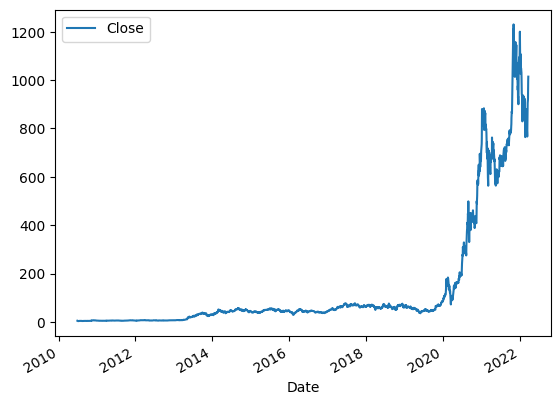

In [ ]:
# Plot the closing price against the date
data.plot(x="Date", y="Close")

<Axes: xlabel='Date'>

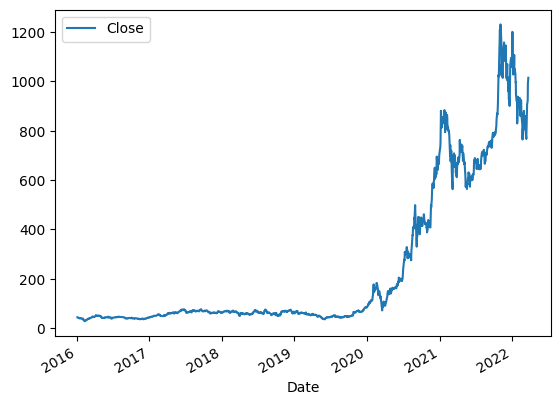

In [ ]:
# For simplicity, take a subset of the data corresponding to after 2016 instead
import datetime
df = data.loc[
    (data['Date'] >= '2016-01-01')
]

df.plot(x="Date", y="Close")

In [ ]:
# Remove all other columns, keeping only the closing price and date
df_subset = df[["Date", "Close"]]

In [ ]:
# Separate the data into training and testing data
# Training data is 90% of the data
# The test data is the remaining 10% (predicted/projected forecast)
train_len = int(np.ceil(len(df_subset) * 0.90))
df_train = df_subset[:train_len].copy()
df_test = df_subset[train_len:].copy()
print(len(df_train))
print(len(df_test))

1412
156


### **Check stationarity of time series**

As mentioned above, the time series must be made stationary.

The ADF (Augmented Dickey-Fuller) test, a statistical test, is used to determine if the time series is stationary:

In [ ]:
from statsmodels.tsa.stattools import adfuller
# Extract the closing price column (not doing so will result in an exog error
# when applying ADF after differencing)
train = df_train["Close"]

# Perform the test
adf_test = adfuller(train)
print(f"p-value is {adf_test[1]}")

p-value is 0.9749673479971513


The large p-value, greater than 0.05, means we do not reject the null hypothesis **(H(0): the time series is not stationary)**. This means that the time series is not stationary.

For normality, we can see clearly from the plots that the closing stock price is also clearly not normally distributed.

With the knowledge that the time series is not stationary,apply **differencing**: subtracting the current observation from the previous one. This removes trends and seasonality from the data.

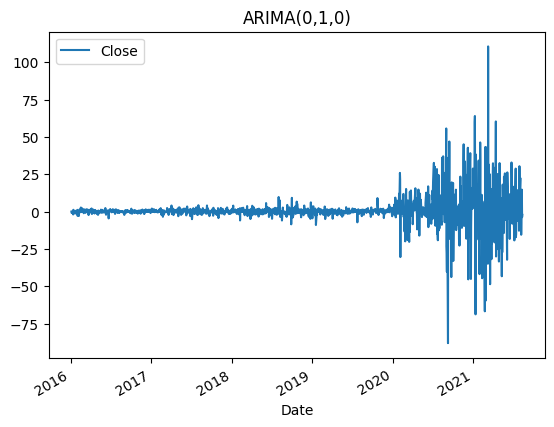

In [ ]:
train = train.diff().dropna()
data = pd.DataFrame(df_train["Date"])
data = pd.concat([data, train], axis = 1)
data.plot(x="Date", y="Close")
plt.title("ARIMA(0,1,0)")
plt.show()

In [ ]:
adf_test = adfuller(train)
print(f"p-value is {adf_test[1]}")

p-value is 1.2078150800989138e-08


The p-value is very small, less than 0.05. Reject the null hypothesis that the time series is not stationary.

As of now, the differencing factor is set at 1. This means at least one order of differencing is needed to stationarize the series. A higher order of differencing may be considered.

### **Autocorrelation and Partial Autocorrelation functions**

The autocorrelation function describes the correlation between a time series and the lagged version of itself (lagged values of a time series refers to past observations of the same variable), across a specified time period.

The partial autocorrelation function describes additional correlation explained by each successive lagged term.

Functions `plot_acf()` and `plot_pacf()` help to plot autocorrelation and partial autocorrelation function plots respectively. Analyzing these plots will determine optimal values for AR and MA terms.

The autocorrelation plot also checks if there are signs of overdifferencing; a big negative spike at lag 1.

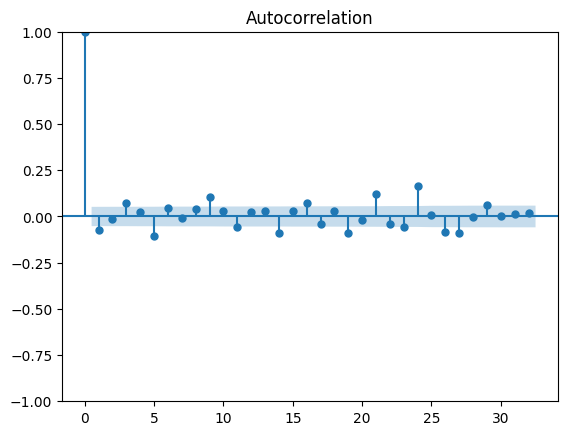

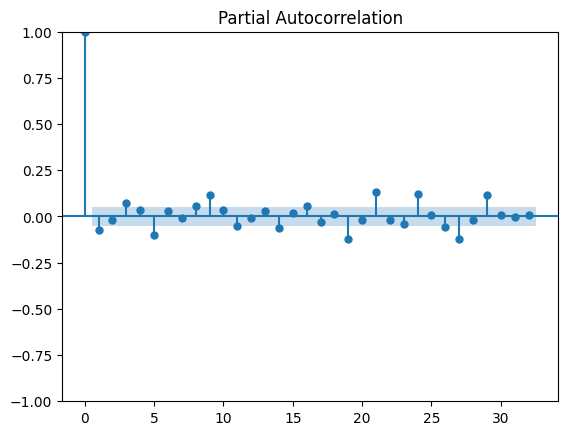

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf_diff = plot_acf(train)
pacf_diff = plot_pacf(train)

The ACF plot confirms that there is no negative spike at lag 1, meaning no overdifferencing. While a higher order of differencing can be considered, I decide to stick to an order of 1.

Given the plots above, and with the time series being made stationary, deduce that there is no conclusion as to whether there is positive or negative autocorrelation.

 The simplest model to fit it is ARIMA(0, 1, 0). No constant is added to the model too, making it a _random walk without drift_ model. However, try fitting ARIMA(1,1,1) instead, taking into account the randomness of the time series.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
training = df_train["Close"]
mod = ARIMA(training, order=(1, 1, 1))
model = mod.fit()
# model.summary()

In [ ]:
# Predict for the test set
predictions = model.predict(start = len(df_train), end = len(df_subset)-1)

In [ ]:
df_test = df_test.reset_index(drop=True)
df_test.head()

,Date,Close
0,2021-08-12,722.250000
1,2021-08-13,717.169983
2,2021-08-16,686.169983
3,2021-08-17,665.710022
4,2021-08-18,688.989990


In [ ]:
predictions = pd.DataFrame(predictions)
predictions = predictions.reset_index(drop=True)
predictions.head()

,predicted_mean
0,707.989447
1,707.989521
2,707.989521
3,707.989521
4,707.989521


In [ ]:
df_test = pd.concat([df_test, predictions], axis=1)

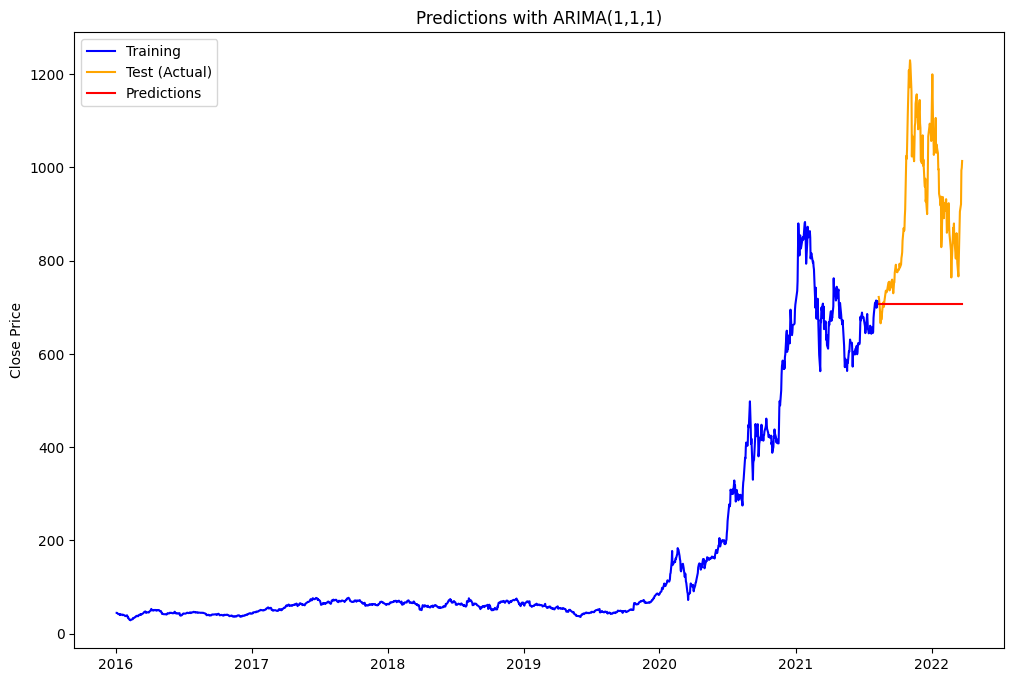

In [ ]:
# Plot actual vs prediction
plt.figure(figsize=(12,8))
plt.plot(df_train["Date"], df_train["Close"], label="Training", color='blue')
plt.plot(df_test["Date"], df_test["Close"], label="Test (Actual)", color='orange')
plt.plot(df_test["Date"], df_test["predicted_mean"], label="Predictions", color='red')
plt.title("Predictions with ARIMA(1,1,1)")
plt.ylabel("Close Price")
plt.legend()
plt.show()

It appears that the predictions remain constant, like a straight line across the forecasted time period.

Attempt to find a better ARIMA model for fitting this time series is to auto-fit to the training data as follows:

In [ ]:
import pmdarima as pm
auto_arima = pm.auto_arima(training, stepwise=False, seasonal=False)
auto_arima

ARIMA(order=(5, 2, 0), scoring_args={}, suppress_warnings=True)

In [ ]:
# Fit using the proposed arima model and predict
new_mod = ARIMA(training, order = (5, 2, 0))
new_model = new_mod.fit()

new_pred = new_model.predict(start=len(df_train), end=len(df_subset)-1)

In [ ]:
df_test = df_test.drop(columns="predicted_mean")
df_test.head()

,Date,Close
0,2021-08-12,722.250000
1,2021-08-13,717.169983
2,2021-08-16,686.169983
3,2021-08-17,665.710022
4,2021-08-18,688.989990


In [ ]:
new_pred = pd.DataFrame(new_pred)
new_pred = new_pred.reset_index(drop=True)
new_pred.head()

,predicted_mean
0,707.958349
1,709.282238
2,706.038893
3,708.225993
4,707.352025


In [ ]:
df_test = pd.concat([df_test, new_pred], axis=1)

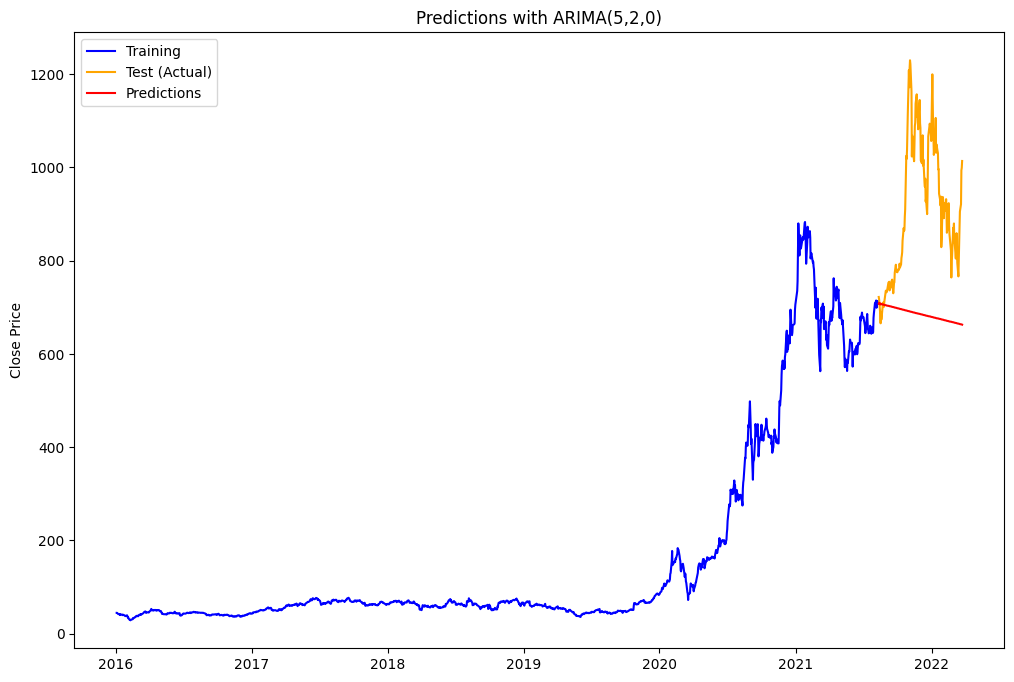

In [ ]:
# Plot actual vs prediction
plt.figure(figsize=(12,8))
plt.plot(df_train["Date"], df_train["Close"], label="Training", color='blue')
plt.plot(df_test["Date"], df_test["Close"], label="Test (Actual)", color='orange')
plt.plot(df_test["Date"], df_test["predicted_mean"], label="Predictions", color='red')
plt.title("Predictions with ARIMA(5,2,0)")
plt.ylabel("Close Price")
plt.legend()
plt.show()

### **Evaluation of ARIMA models**

Observing both plots' predicted vs actual trends from both ARIMA models, ARIMA models are not accurate in predicting stock prices. This could be the reason of ARIMA being a linear model; having the inability to learn the non-linear dynamics of stock price data. It is also not good at long-term forecasting.

Statistical methods like ARIMA and other variants using autoregression are not effective in stock price forecasting. More complex models like machine learning models are suited for such data.

### **Experimenting with Prophet framework**

The section below focuses on using `Prophet`, a microframework made for working with financial data. The open-source library is already implemented in Python, so import as follows:

In [81]:
from prophet import Prophet

# Extract both the closing price and date columns
df_subset = df[['Date', 'Close']]

In [82]:
# Separate the data into training and testing data
# Training data is 90% of the data
# The test data is the remaining 10% (predicted/projected forecast)
train_len = int(np.ceil(len(df_subset) * 0.90))
df_train = df_subset[:train_len].copy()
df_test = df_subset[train_len:].copy()

In [83]:
# Rename the specific columns
# Input to Prophet is always a dataframe with two columns ds and y
df_train = df_train.rename(columns={'Date': 'ds', 'Close': 'y'})

In [84]:
# Call the model to fit the training data
frame = Prophet()
frame.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


By default, `daily_seaonality` is set to False, because I do not want to consider seasonality when fitting the data

In [ ]:
# Check the ending dates for the training set and test set
print(df_train.tail())
print(df_test.tail())

             ds           y
2845 2021-10-15  843.030029
2846 2021-10-18  870.109985
2847 2021-10-19  864.270020
2848 2021-10-20  865.799988
2849 2021-10-21  894.000000
           Date        Close
2951 2022-03-18   905.390015
2952 2022-03-21   921.159973
2953 2022-03-22   993.979980
2954 2022-03-23   999.109985
2955 2022-03-24  1013.919983


Given that there are days where the TSLA stock market is closed (on weekends), taking that into account, the number of days that should be counted is not the same as the number given in the size of the test data set.

In [ ]:
from datetime import date
d1 = date(2021, 10, 21)
d2 = date(2022, 3, 24)
days = (d2-d1).days
print(days)

154


In [ ]:
# Since there are 154 days in the test data set, get the model to predict these future days
forecast = frame.make_future_dataframe(periods = 154, freq = 'D')
# Clarify that these are indeed the future dates to be predicted
print(forecast.tail())
print(forecast.head())

             ds
1108 2022-03-20
1109 2022-03-21
1110 2022-03-22
1111 2022-03-23
1112 2022-03-24
          ds
0 2018-01-02
1 2018-01-03
2 2018-01-04
3 2018-01-05
4 2018-01-08


The `make_future_dataframe()` method extends into the future the specified number of days. This dataframe created also includes the dates from the training data set.

In [ ]:
# Now we will predict the future
forecasted = frame.predict(forecast)
forecasted.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1108,2022-03-20,812.539376,766.463542,909.493137,758.229159,861.649822,25.198478,25.198478,25.198478,30.234452,30.234452,30.234452,-5.035974,-5.035974,-5.035974,0.0,0.0,0.0,837.737855
1109,2022-03-21,812.850454,721.282400,863.109024,757.660264,862.763336,-17.935016,-17.935016,-17.935016,-11.851060,-11.851060,-11.851060,-6.083956,-6.083956,-6.083956,0.0,0.0,0.0,794.915438
1110,2022-03-22,813.161532,724.312584,862.103981,757.328472,863.797064,-18.584789,-18.584789,-18.584789,-11.535009,-11.535009,-11.535009,-7.049779,-7.049779,-7.049779,0.0,0.0,0.0,794.576743
1111,2022-03-23,813.472609,724.051175,858.935354,756.963301,864.366034,-19.666374,-19.666374,-19.666374,-11.738945,-11.738945,-11.738945,-7.927429,-7.927429,-7.927429,0.0,0.0,0.0,793.806236
1112,2022-03-24,813.783687,720.616456,859.814454,756.611046,864.951527,-20.852827,-20.852827,-20.852827,-12.142922,-12.142922,-12.142922,-8.709904,-8.709904,-8.709904,0.0,0.0,0.0,792.930860


The `predict()` method assigns to each day, a predicted closing stock price value. These values are in the column `yhat` inside the dataframe.

Along with the `yhat` column, the dataframe has other columns for seasonal components and uncertainty intervals.

<Axes: xlabel='Date'>

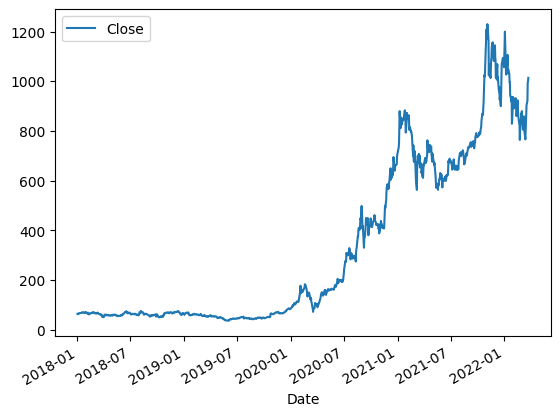

In [ ]:
# Plot the actual trend
df_subset.plot(x='Date', y='Close')

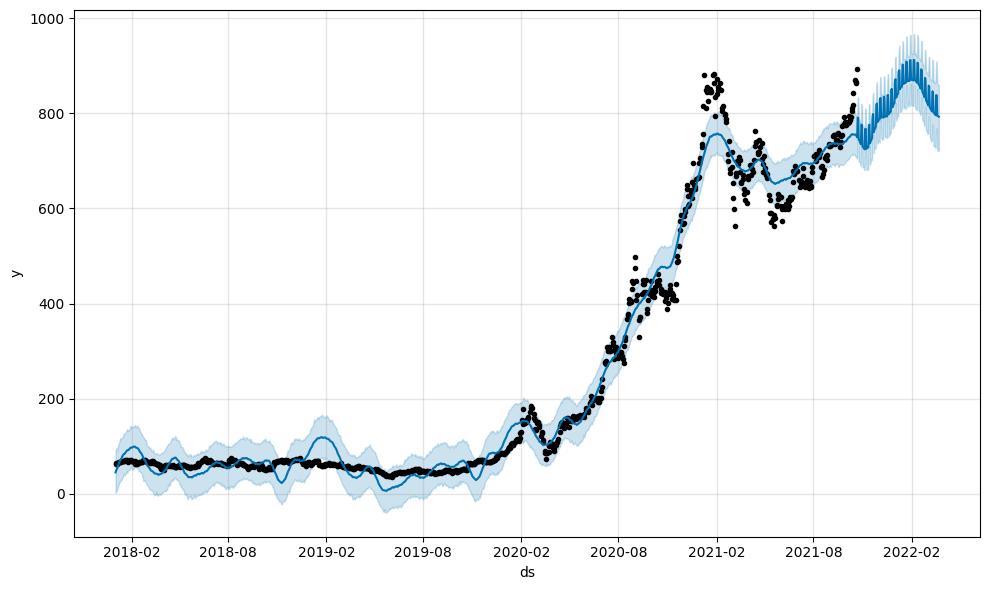

In [ ]:
# Plot the forecasted trend
fig = frame.plot(forecasted)

The predicted portion shows an increasing trend, reaching a peak, followed by a decreasing one, quite similar to the actual plot. While the actual increase is way more significant than the prediction, both plots show that the closing price drops to close to 800 at the end.

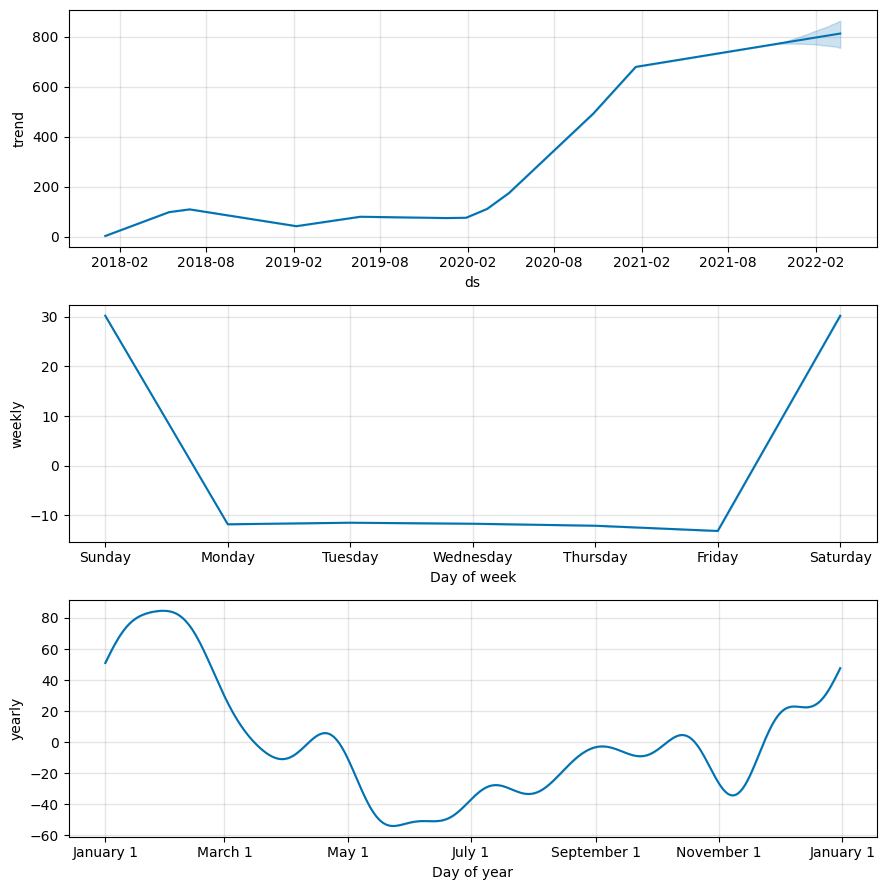

In [ ]:
# To see the forecast components
components = frame.plot_components(forecasted)

In the plots above, the yearly, weekly and monthly seasonality trends are captured efficiently.

An interactive figure of the forecast and its components can even be created with plotly.